In [1]:
# ==========================================================
# 1. Imports
# ==========================================================

import os
import re
import cv2
import torch
import random
import numpy as np
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_losses      = []
val_losses        = []
train_accuracies  = []
val_accuracies    = []
lr_cls_history    = []
lr_enc_history    = []


# ==========================================================
# 2. Breast Segmentation Model (U-Net)
# ==========================================================

class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, 1, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)        # 1-channel grayscale input
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.up1 = DoubleConv(256 + 128, 128)
        self.up2 = DoubleConv(128 + 64, 64)

        self.up    = nn.Upsample(scale_factor=2, mode='bilinear')
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool(d1)

        d2 = self.down2(p1)
        p2 = self.pool(d2)

        d3 = self.down3(p2)

        u1 = self.up(d3)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.up1(u1)

        u2 = self.up(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up2(u2)

        return torch.sigmoid(self.final(u2))

seg_model = UNet().to(device)


# ==========================================================
# 3. Gabor Filter Bank
# ==========================================================

def build_gabor_bank():

    kernels = []

    for theta in np.arange(0, np.pi, np.pi / 8):
        for sigma in (2, 4, 6):
            kernels.append(
                cv2.getGaborKernel((21, 21), sigma, theta, 10, 0.5)
            )

    return kernels

gabor_kernels = build_gabor_bank()


def apply_gabor(img):
    """
    Returns a single-channel (L-mode) PIL image.
    Images are grayscale; keeping them as 1-channel avoids wasting 2/3 of
    ResNet's first-layer capacity on duplicate channels.
    """
    img = np.array(img.convert("RGB"))

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    responses = []

    for k in gabor_kernels:
        responses.append(cv2.filter2D(gray, cv2.CV_32F, k))

    r = np.max(np.stack(responses), axis=0)

    r = cv2.normalize(r, None, 0, 255, cv2.NORM_MINMAX)

    # Return grayscale PIL (mode "L") — single channel
    return Image.fromarray(r.astype(np.uint8))


# ==========================================================
# 4. Transforms
# ==========================================================

ssl_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.GaussianBlur(3),
    T.ToTensor()          # (1, H, W) for grayscale PIL
])

cls_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()          # (1, H, W) for grayscale PIL
])


# ==========================================================
# 5. Quadrants + Multi-scale patches
# ==========================================================

def split_quadrants(img):
    """img: (C, H, W) tensor"""
    c, h, w = img.shape
    h2, w2  = h // 2, w // 2

    return [
        img[:, 0:h2,  0:w2],
        img[:, 0:h2,  w2:w],
        img[:, h2:h,  0:w2],
        img[:, h2:h,  w2:w]
    ]


def extract_patches(img):
    """img: (C, H, W) tensor"""
    c, h, w = img.shape

    patches = []
    sizes   = [56, 112]

    for s in sizes:
        for _ in range(2):
            y = random.randint(0, h - s)
            x = random.randint(0, w - s)
            patches.append(img[:, y:y + s, x:x + s])

    return patches


# ==========================================================
# 6. Regex Label Extraction
# ==========================================================

def extract_label(name):

    if re.search("malignant", name, re.I):
        return 1

    if re.search("benign", name, re.I):
        return 0

    return -1


# ==========================================================
# 7. SSL Dataset
# ==========================================================

class SSLDataset(Dataset):

    def __init__(self, folder):
        self.files = glob(folder + "/*")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = Image.open(self.files[idx])   # apply_gabor handles mode internally

        img = apply_gabor(img)              # returns grayscale PIL (mode "L")

        view1 = ssl_transform(img)          # (1, 224, 224)
        view2 = ssl_transform(img)

        quads   = split_quadrants(view1)
        patches = extract_patches(view1)

        # ToPILImage on a (1,H,W) float tensor gives mode "F";
        # convert to "L" before feeding back into ssl_transform
        quad_aug1  = torch.stack([ssl_transform(T.ToPILImage()(q).convert("L")) for q in quads])
        quad_aug2  = torch.stack([ssl_transform(T.ToPILImage()(q).convert("L")) for q in quads])

        patch_aug1 = torch.stack([ssl_transform(T.ToPILImage()(p).convert("L")) for p in patches])
        patch_aug2 = torch.stack([ssl_transform(T.ToPILImage()(p).convert("L")) for p in patches])

        return view1, view2, quad_aug1, quad_aug2, patch_aug1, patch_aug2


# ==========================================================
# 8. Supervised Dataset
# ==========================================================

class ThermoDataset(Dataset):

    def __init__(self, folder):
        self.files = glob(folder + "/*")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        img = Image.open(path)

        img = apply_gabor(img)       # grayscale PIL (mode "L")

        img = cls_transform(img)     # (1, 224, 224)

        label = extract_label(path)

        return img, label


# ==========================================================
# 9. Encoder
# First conv is 1-channel to match grayscale input
# ==========================================================

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        base = resnet50(weights=None)

        # Replace first conv: 3 → 1 input channel (grayscale)
        base.conv1 = nn.Conv2d(
            1, 64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        self.backbone  = nn.Sequential(*list(base.children())[:-2])

        self.pool      = nn.AdaptiveAvgPool2d((1, 1))

        self.projector = nn.Linear(2048, 512)

    def forward(self, x):

        fmap = self.backbone(x)

        g = self.pool(fmap)
        g = g.view(g.size(0), -1)      # (B, 2048)

        g = self.projector(g)          # (B, 512) — SSL-trained representation

        return fmap, g


# ==========================================================
# 10. Gated Fusion
# Fuses avg+max pooled spatial features with the SSL projection g
# ==========================================================

class GatedFusion(nn.Module):

    def __init__(self, spatial_dim=4096, ssl_dim=512, out_dim=512):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(spatial_dim + ssl_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
            nn.Sigmoid()
        )

        self.proj_spatial = nn.Linear(spatial_dim, out_dim)
        self.proj_ssl     = nn.Linear(ssl_dim, out_dim)

    def forward(self, spatial_feat, ssl_feat):
        """
        spatial_feat : (B, 4096)  — avg + max pooled backbone features
        ssl_feat     : (B, 512)   — SSL projector output
        returns      : (B, out_dim)
        """
        combined = torch.cat([spatial_feat, ssl_feat], dim=1)   # (B, 4608)

        gate = self.gate(combined)                               # (B, 512)

        fused = gate * self.proj_spatial(spatial_feat) \
              + (1 - gate) * self.proj_ssl(ssl_feat)             # (B, 512)

        return fused


# ==========================================================
# 11. VICReg Loss
# ==========================================================

def vicreg(x, y):

    sim = nn.functional.mse_loss(x, y)

    std_x = torch.sqrt(x.var(0) + 1e-4)
    std_y = torch.sqrt(y.var(0) + 1e-4)

    var  = torch.mean(nn.functional.relu(1 - std_x))
    var += torch.mean(nn.functional.relu(1 - std_y))

    return sim + var


# ==========================================================
# 12. Symmetry Loss
# ==========================================================

def symmetry_loss(fmap):

    flipped = torch.flip(fmap, [3])

    return torch.mean((fmap - flipped) ** 2)


# ==========================================================
# 13. SSL Pretraining
# ✅ UPDATED: Gradient accumulation (effective batch 32 from physical 8)
# ✅ UPDATED: Mixed precision (autocast + GradScaler)
# ✅ UPDATED: Stacked forward passes for quadrants and patches
# ==========================================================

def pretrain(model, loader, epochs=60):

    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # Single cosine scheduler — no conflict
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )

    # ✅ Mixed precision scaler — halves GPU memory usage almost for free
    scaler = torch.cuda.amp.GradScaler()

    # ✅ Effective batch size = physical batch (8) × accumulation steps (4) = 32
    ACCUMULATION_STEPS = 4

    for epoch in range(epochs):

        total_loss = 0

        # ✅ zero_grad outside the batch loop — gradients accumulate across steps
        optimizer.zero_grad()

        for step, (v1, v2, quad_aug1, quad_aug2, patch_aug1, patch_aug2) in enumerate(loader):

            v1 = v1.to(device)
            v2 = v2.to(device)

            # ✅ All forward passes wrapped in autocast for mixed precision
            with torch.cuda.amp.autocast():

                fmap1, g1 = model(v1)
                fmap2, g2 = model(v2)

                loss_global = vicreg(g1, g2)

                # ✅ Stack all quadrant pairs into one forward pass instead of
                #    looping — same compute, much less peak memory because
                #    intermediate activations are not all held alive simultaneously
                B, N, C, H, W = quad_aug1.shape

                q1_all = quad_aug1.view(B * N, C, H, W).to(device)
                q2_all = quad_aug2.view(B * N, C, H, W).to(device)

                _, z1_quads = model(q1_all)
                _, z2_quads = model(q2_all)

                z1_quads = z1_quads.view(B, N, -1).unbind(dim=1)
                z2_quads = z2_quads.view(B, N, -1).unbind(dim=1)

                quad_losses = [vicreg(z1, z2) for z1, z2 in zip(z1_quads, z2_quads)]

                # ✅ Same stacking trick for patches
                Bp, Np, Cp, Hp, Wp = patch_aug1.shape

                p1_all = patch_aug1.view(Bp * Np, Cp, Hp, Wp).to(device)
                p2_all = patch_aug2.view(Bp * Np, Cp, Hp, Wp).to(device)

                _, z1_patches = model(p1_all)
                _, z2_patches = model(p2_all)

                z1_patches = z1_patches.view(Bp, Np, -1).unbind(dim=1)
                z2_patches = z2_patches.view(Bp, Np, -1).unbind(dim=1)

                patch_losses = [vicreg(z1, z2) for z1, z2 in zip(z1_patches, z2_patches)]

                local_losses = quad_losses + patch_losses

                loss_local = sum(local_losses) / len(local_losses)

                loss_sym = symmetry_loss(fmap1)

                # ✅ Scale loss by accumulation steps so effective gradient
                #    magnitude matches a true batch of 32
                loss = (loss_global + loss_local + loss_sym) / ACCUMULATION_STEPS

            # ✅ Scaler backward — works correctly with mixed precision
            scaler.scale(loss).backward()

            # ✅ Log unscaled loss for interpretable printing
            total_loss += loss.item() * ACCUMULATION_STEPS

            # ✅ Step optimizer only every ACCUMULATION_STEPS batches
            if (step + 1) % ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                torch.cuda.empty_cache()

        # ✅ Handle leftover steps if dataset size isn't divisible by ACCUMULATION_STEPS
        if (step + 1) % ACCUMULATION_STEPS != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        scheduler.step()

        print("SSL Epoch:", epoch, "Loss:", total_loss / len(loader))

        torch.cuda.empty_cache()

    torch.save(model.state_dict(),
               "/kaggle/working/pretrained_encoder.pth")

    print("Pretrained encoder saved")


# ==========================================================
# 14. Classifier
# ClassifierHead input = 512 (fused output from GatedFusion)
# ThermoClassifier uses GatedFusion to combine spatial + SSL features
# ==========================================================

class ClassifierHead(nn.Module):

    def __init__(self, in_dim=512):
        super().__init__()

        self.net = nn.Sequential(

            nn.LayerNorm(in_dim),

            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)


class ThermoClassifier(nn.Module):

    def __init__(self, encoder):
        super().__init__()

        self.encoder = encoder

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.maxpool = nn.AdaptiveMaxPool2d((1, 1))

        # GatedFusion combines spatial features with SSL projection g
        self.fusion = GatedFusion(spatial_dim=4096, ssl_dim=512, out_dim=512)

        self.classifier = ClassifierHead(in_dim=512)

    def forward(self, x):

        fmap, g = self.encoder(x)                              # fmap: (B,2048,7,7), g: (B,512)

        avg = self.avgpool(fmap).view(x.size(0), -1)           # (B, 2048)
        mx  = self.maxpool(fmap).view(x.size(0), -1)           # (B, 2048)

        spatial = torch.cat([avg, mx], dim=1)                  # (B, 4096)

        fused = self.fusion(spatial, g)                        # (B, 512)

        return self.classifier(fused)


# ==========================================================
# 15. Training + Validation Tracking
# ✅ UPDATED: Mixed precision (autocast + GradScaler)
# Single scheduler (cosine with warmup via LambdaLR)
# Gradual encoder unfreezing (layer-by-layer)
# ==========================================================

def train_classifier(model, train_loader, val_loader, epochs=60):

    # Start with encoder fully frozen
    for p in model.encoder.parameters():
        p.requires_grad = False

    optimizer = optim.AdamW([
        {"params": model.classifier.parameters(), "lr": 1e-3},
        {"params": model.fusion.parameters(),      "lr": 1e-3},
        {"params": model.encoder.parameters(),     "lr": 1e-5}
    ])

    # ✅ Mixed precision scaler for fine-tuning
    scaler = torch.amp.GradScaler('cuda')

    warmup_epochs = 5

    # ONE scheduler only — cosine with linear warmup; no ReduceLROnPlateau conflict
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=[
            # classifier: warmup → cosine
            lambda epoch: (
                (epoch + 1) / warmup_epochs
                if epoch < warmup_epochs
                else 0.5 * (1 + np.cos(
                    np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)
                ))
            ),
            # fusion head: same schedule as classifier
            lambda epoch: (
                (epoch + 1) / warmup_epochs
                if epoch < warmup_epochs
                else 0.5 * (1 + np.cos(
                    np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)
                ))
            ),
            # encoder: slow cosine, no warmup
            lambda epoch: 0.5 * (1 + np.cos(np.pi * epoch / (epochs * 2)))
        ]
    )

    ce = nn.CrossEntropyLoss()

    best_val_acc = 0

    for epoch in range(epochs):

        # Gradual layer-by-layer unfreezing
        if epoch == 5:
            for p in model.encoder.backbone[-1].parameters():
                p.requires_grad = True
            print("Epoch 5: Unfroze encoder last block")

        if epoch == 15:
            for p in model.encoder.backbone[-2].parameters():
                p.requires_grad = True
            print("Epoch 15: Unfroze encoder second-to-last block")

        if epoch == 25:
            for p in model.encoder.parameters():
                p.requires_grad = True
            print("Epoch 25: Unfroze entire encoder")

        model.train()

        preds      = []
        gts        = []
        total_loss = 0

        for img, label in train_loader:

            img   = img.to(device)
            label = label.to(device)

            # ✅ Mixed precision forward pass
            with torch.amp.autocast('cuda'):
                out  = model(img)
                loss = ce(out, label)

            optimizer.zero_grad()
            scaler.scale(loss).backward()   # ✅
            scaler.step(optimizer)          # ✅
            scaler.update()                 # ✅

            total_loss += loss.item()

            preds += out.argmax(1).cpu().tolist()
            gts   += label.cpu().tolist()

        train_acc = accuracy_score(gts, preds)

        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_acc)

        model.eval()

        v_preds  = []
        v_gts    = []
        val_loss = 0

        with torch.no_grad():

            for img, label in val_loader:

                img   = img.to(device)
                label = label.to(device)

                # ✅ Mixed precision for validation too
                with torch.amp.autocast('cuda'):
                    out  = model(img)
                    loss = ce(out, label)

                val_loss += loss.item()

                v_preds += out.argmax(1).cpu().tolist()
                v_gts   += label.cpu().tolist()

        val_acc = accuracy_score(v_gts, v_preds)

        # Single scheduler step
        scheduler.step()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        lr_cls = optimizer.param_groups[0]['lr']
        lr_enc = optimizer.param_groups[2]['lr']

        lr_cls_history.append(lr_cls)
        lr_enc_history.append(lr_enc)

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(model.state_dict(),
                       "/kaggle/working/final_finetuned_model.pth")

            print("Best model saved  (val_acc={:.4f})".format(val_acc))

        print("Epoch", epoch,
              "| Train Acc:", round(train_acc, 4),
              "| Val Acc:",   round(val_acc, 4),
              "| LR_cls:",    round(lr_cls, 6),
              "| LR_enc:",    round(lr_enc, 8))

        torch.cuda.empty_cache()


# ==========================================================
# 16. Evaluation + Metrics
# ✅ UPDATED: Mixed precision (autocast inside torch.no_grad)
# ==========================================================

def evaluate(model, loader):

    model.eval()

    preds = []
    gts   = []

    with torch.no_grad():

        for img, label in loader:

            img = img.to(device)

            # ✅ Mixed precision — consistent with training, saves memory during TTA
            with torch.cuda.amp.autocast():
                out1 = model(img)
                out2 = model(torch.flip(img, [3]))   # horizontal flip
                out3 = model(torch.flip(img, [2]))   # vertical flip

            # Average predictions (TTA)
            out = (out1 + out2 + out3) / 3

            preds += out.argmax(1).cpu().tolist()
            gts   += label.tolist()

    acc = accuracy_score(gts, preds)
    f1  = f1_score(gts, preds)

    print("Test Accuracy:", acc)
    print("F1 Score:",      f1)

    cm = confusion_matrix(gts, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report\n")
    print(classification_report(gts, preds,
          target_names=["Benign", "Malignant"]))


# ==========================================================
# 17. Training Curves
# ==========================================================

def plot_training():

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses,   label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, label="Train Acc")
    plt.plot(epochs, val_accuracies,   label="Val Acc")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 3, 3)
    plt.plot(epochs, lr_cls_history, label="Classifier LR")
    plt.plot(epochs, lr_enc_history, label="Encoder LR")
    plt.legend()
    plt.title("Learning Rates")

    plt.tight_layout()
    plt.show()


def plot_lr_vs_loss():

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(lr_cls_history, train_losses, marker='o')
    plt.xlabel("Classifier LR")
    plt.ylabel("Train Loss")
    plt.title("Loss vs LR (Classifier)")

    plt.subplot(1, 2, 2)
    plt.plot(lr_enc_history, train_losses, marker='o')
    plt.xlabel("Encoder LR")
    plt.ylabel("Train Loss")
    plt.title("Loss vs LR (Encoder)")

    plt.tight_layout()
    plt.show()




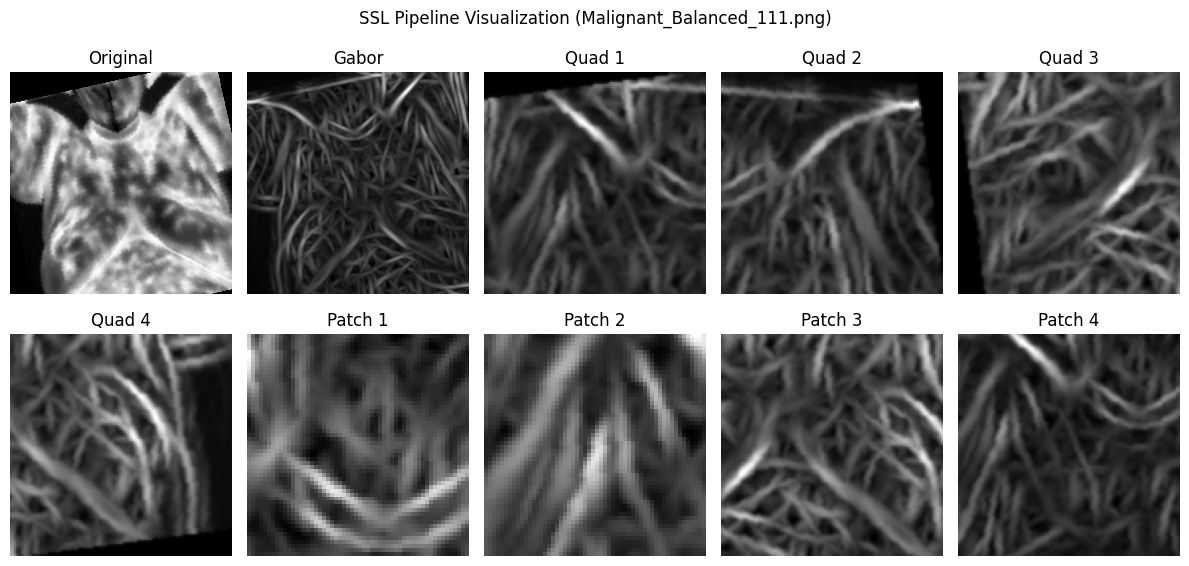

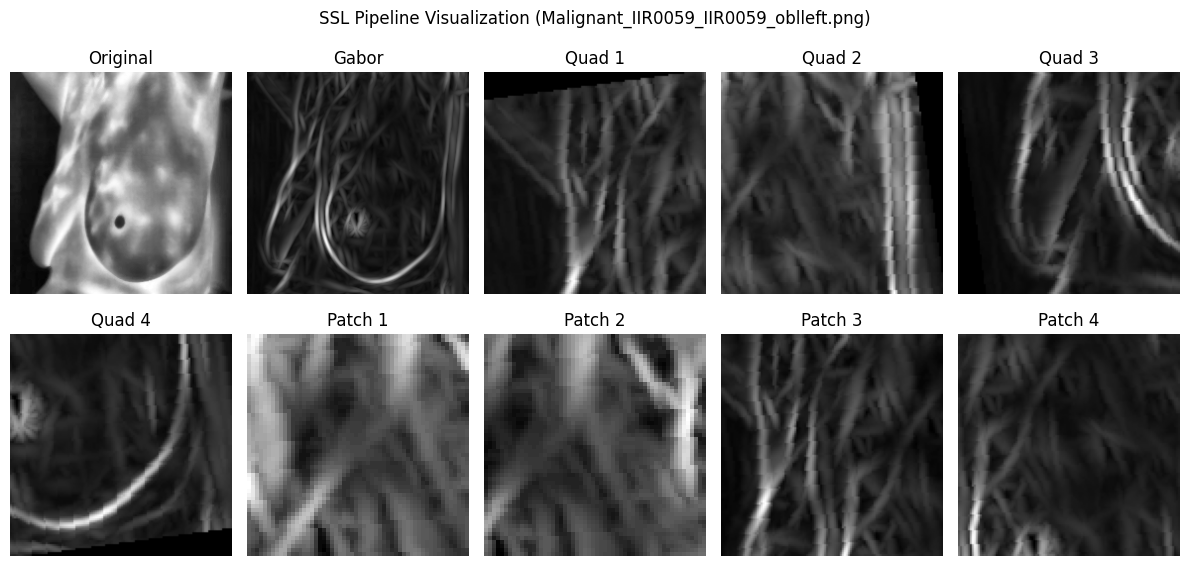

In [2]:
# ==========================================================
# Visualization: Original vs Gabor vs Quadrants vs Patches
# ==========================================================

def visualize_ssl_pipeline(folder, num_images=2):

    files = glob(folder + "/*")

    if len(files) == 0:
        print("No images found in folder.")
        return

    samples = random.sample(files, min(num_images, len(files)))

    for idx, path in enumerate(samples):

        # -----------------------------
        # Load original image
        # ✅ FIX: keep original as RGB only for display purposes
        # -----------------------------
        original = Image.open(path).convert("RGB")

        # -----------------------------
        # Apply Gabor preprocessing
        # ✅ FIX: apply_gabor now returns grayscale PIL (mode "L")
        # -----------------------------
        gabor_img = apply_gabor(original)   # (mode "L")

        # ✅ FIX: ssl_transform on a grayscale PIL gives (1, H, W) tensor
        tensor_img = ssl_transform(gabor_img)

        # -----------------------------
        # Extract quadrants and patches
        # -----------------------------
        quads   = split_quadrants(tensor_img)
        patches = extract_patches(tensor_img)

        # -----------------------------
        # Plot
        # -----------------------------
        plt.figure(figsize=(12, 6))

        # Original — still RGB, display normally
        plt.subplot(2, 5, 1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        # Gabor — mode "L" PIL, imshow handles it directly
        plt.subplot(2, 5, 2)
        plt.imshow(gabor_img, cmap="gray")   # ✅ FIX: use cmap="gray" for L-mode
        plt.title("Gabor")
        plt.axis("off")

        # Quadrants — each is (1, H, W); squeeze to (H, W) for display
        for i, q in enumerate(quads):

            plt.subplot(2, 5, 3 + i)

            # ✅ FIX: squeeze out channel dim → (H, W) numpy array
            q_img = q.squeeze(0).numpy()
            plt.imshow(q_img, cmap="gray")

            plt.title(f"Quad {i + 1}")
            plt.axis("off")

        # Patches — same squeeze treatment
        for i, p in enumerate(patches[:4]):

            plt.subplot(2, 5, 7 + i)

            # ✅ FIX: squeeze out channel dim → (H, W) numpy array
            p_img = p.squeeze(0).numpy()
            plt.imshow(p_img, cmap="gray")

            plt.title(f"Patch {i + 1}")
            plt.axis("off")

        plt.suptitle(f"SSL Pipeline Visualization ({os.path.basename(path)})")
        plt.tight_layout()
        plt.show()


# Example usage
visualize_ssl_pipeline(
    "/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/train_i",
    num_images=2
)




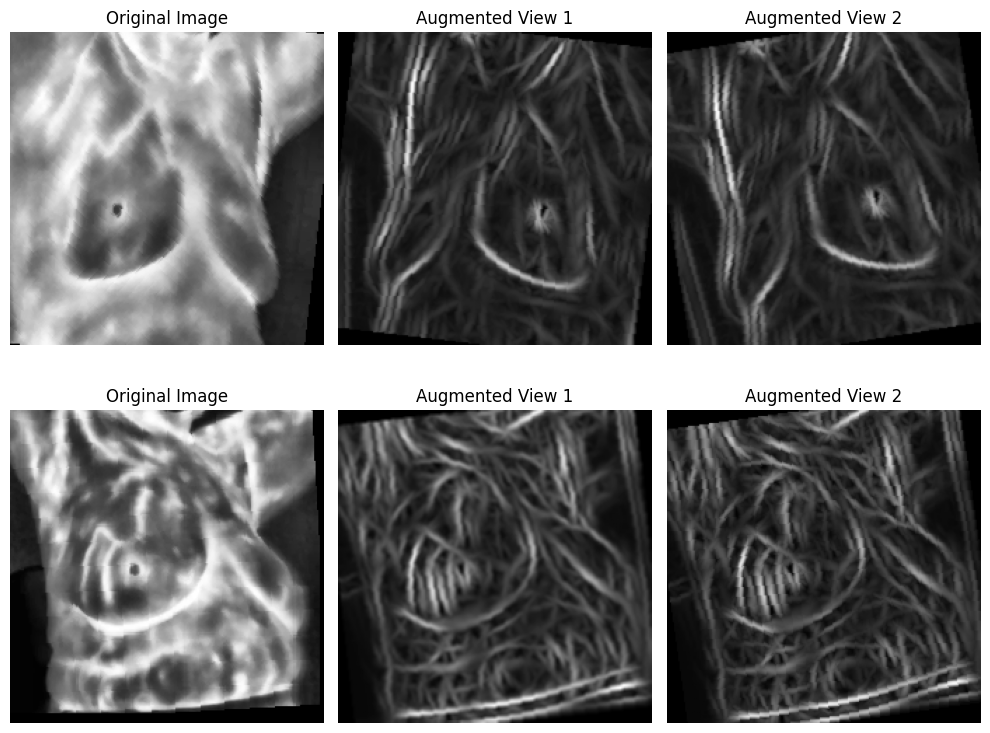

In [3]:
# ==========================================================
# Visualization: VICReg Augmented Views
# ==========================================================

def visualize_ssl_views(folder, num_images=3):

    files = glob(folder + "/*")

    if len(files) == 0:
        print("No images found.")
        return

    samples = random.sample(files, min(num_images, len(files)))

    plt.figure(figsize=(10, 4 * num_images))

    for i, path in enumerate(samples):

        # Original — load as RGB only for display
        original = Image.open(path).convert("RGB")

        # ✅ FIX: apply_gabor returns grayscale PIL (mode "L")
        gabor_img = apply_gabor(original)

        # Two SSL augmentations — tensors are (1, H, W)
        view1 = ssl_transform(gabor_img)
        view2 = ssl_transform(gabor_img)

        # ✅ FIX: squeeze channel dim → (H, W) numpy for grayscale display
        #         Old code did .permute(1,2,0) which gave (H, W, 1) and
        #         could cause imshow complaints; squeeze is cleaner
        view1_np = view1.squeeze(0).numpy()
        view2_np = view2.squeeze(0).numpy()

        # Plot original (RGB)
        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(original)
        plt.title("Original Image")
        plt.axis("off")

        # Plot augmentation 1
        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(view1_np, cmap="gray")   # ✅ FIX: cmap="gray" for (H,W) array
        plt.title("Augmented View 1")
        plt.axis("off")

        # Plot augmentation 2
        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(view2_np, cmap="gray")   # ✅ FIX: cmap="gray" for (H,W) array
        plt.title("Augmented View 2")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Example usage
visualize_ssl_views(
    "/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/train_i",
    num_images=2
)

In [4]:
# ==========================================================
# 18. DataLoaders
# ==========================================================

ssl_loader = DataLoader(
    SSLDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/train_i"),
    batch_size=8,          # physical batch; ×4 accumulation = effective 32
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True         # avoids undersized final batch corrupting VICReg variance
)

train_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/train_i"),
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True         # avoids a 1-2 sample batch skewing the loss
)

val_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/val_i"),
    batch_size=16,
    shuffle=False,         # never shuffle validation
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/test_i"),
    batch_size=16,
    shuffle=False,
    num_workers=4,         # was missing
    pin_memory=True        # was missing
)




In [5]:
# ==========================================================
# 19. Main Execution
# ==========================================================

encoder = Encoder().to(device)

pretrained_path = "/kaggle/input/datasets/lilyofthevalley6666/bt-pretrained-encoder-params/pretrained_encoder.pth"

if os.path.exists(pretrained_path):
    print("Loading pretrained encoder...")
    # ✅ map_location ensures safe loading on both CPU and GPU machines
    encoder.load_state_dict(torch.load(pretrained_path, map_location=device))
else:
    print("Pretraining encoder...")
    pretrain(encoder, ssl_loader, epochs=60)
    encoder.load_state_dict(torch.load(
        "/kaggle/working/pretrained_encoder.pth", map_location=device
    ))



Pretraining encoder...


/tmp/ipykernel_23/2722891559.py:389: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_23/2722891559.py:407: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


SSL Epoch: 0 Loss: 2.3650487287839255
SSL Epoch: 1 Loss: 0.578196986913681
SSL Epoch: 2 Loss: 0.26609345893065134
SSL Epoch: 3 Loss: 0.182707007676363
SSL Epoch: 4 Loss: 0.13411958848436673
SSL Epoch: 5 Loss: 0.10698633107046286
SSL Epoch: 6 Loss: 0.09242124132812023
SSL Epoch: 7 Loss: 0.07249071091413498
SSL Epoch: 8 Loss: 0.06740644159416358
SSL Epoch: 9 Loss: 0.0541495489453276
SSL Epoch: 10 Loss: 0.05339756146073341
SSL Epoch: 11 Loss: 0.04626097273081541
SSL Epoch: 12 Loss: 0.042458553835749625
SSL Epoch: 13 Loss: 0.043351627849042416
SSL Epoch: 14 Loss: 0.035595272618035474
SSL Epoch: 15 Loss: 0.03614716102679571
SSL Epoch: 16 Loss: 0.03642371802901228
SSL Epoch: 17 Loss: 0.028589018204559884
SSL Epoch: 18 Loss: 0.029954649036129315
SSL Epoch: 19 Loss: 0.028752980263282855
SSL Epoch: 20 Loss: 0.02587508230780562
SSL Epoch: 21 Loss: 0.027113036538163823
SSL Epoch: 22 Loss: 0.02663222890968124
SSL Epoch: 23 Loss: 0.02558562113593022
SSL Epoch: 24 Loss: 0.02156618541106582
SSL Epoch

Loading pretrained encoder...
Best model saved  (val_acc=0.5000)
Epoch 0 | Train Acc: 0.5217 | Val Acc: 0.5 | LR_cls: 0.0004 | LR_enc: 1e-05
Best model saved  (val_acc=0.5556)
Epoch 1 | Train Acc: 0.5292 | Val Acc: 0.5556 | LR_cls: 0.0006 | LR_enc: 9.99e-06
Epoch 2 | Train Acc: 0.5292 | Val Acc: 0.5486 | LR_cls: 0.0008 | LR_enc: 9.98e-06
Epoch 3 | Train Acc: 0.5092 | Val Acc: 0.4792 | LR_cls: 0.001 | LR_enc: 9.97e-06
Epoch 4 | Train Acc: 0.5033 | Val Acc: 0.5139 | LR_cls: 0.001 | LR_enc: 9.96e-06
Epoch 5: Unfroze encoder last block
Epoch 5 | Train Acc: 0.5367 | Val Acc: 0.5 | LR_cls: 0.000999 | LR_enc: 9.94e-06
Epoch 6 | Train Acc: 0.5142 | Val Acc: 0.5347 | LR_cls: 0.000997 | LR_enc: 9.92e-06
Epoch 7 | Train Acc: 0.565 | Val Acc: 0.5208 | LR_cls: 0.000993 | LR_enc: 9.89e-06
Epoch 8 | Train Acc: 0.5925 | Val Acc: 0.5208 | LR_cls: 0.000987 | LR_enc: 9.86e-06
Epoch 9 | Train Acc: 0.6158 | Val Acc: 0.5417 | LR_cls: 0.00098 | LR_enc: 9.83e-06
Epoch 10 | Train Acc: 0.6125 | Val Acc: 0.5208 

/tmp/ipykernel_23/2722891559.py:720: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Test Accuracy: 0.7160493827160493
F1 Score: 0.7526881720430108


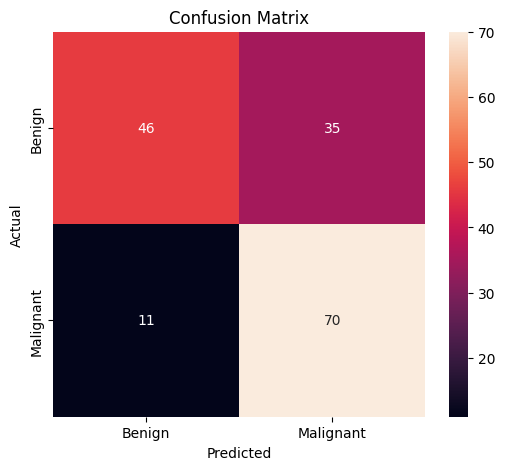


Classification Report

              precision    recall  f1-score   support

      Benign       0.81      0.57      0.67        81
   Malignant       0.67      0.86      0.75        81

    accuracy                           0.72       162
   macro avg       0.74      0.72      0.71       162
weighted avg       0.74      0.72      0.71       162



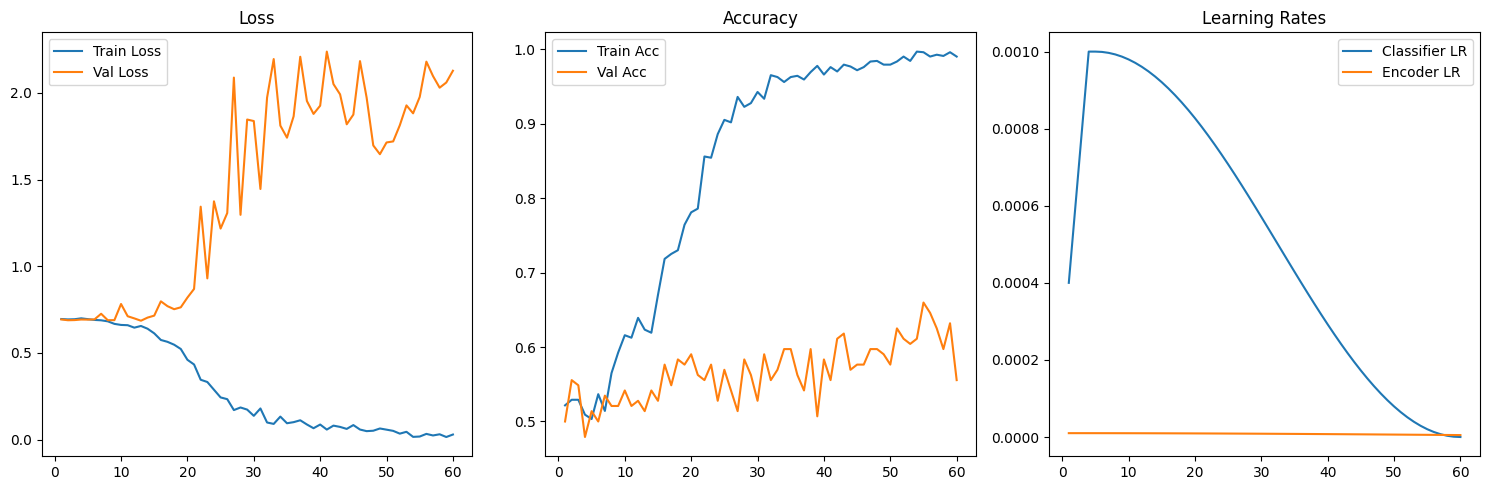

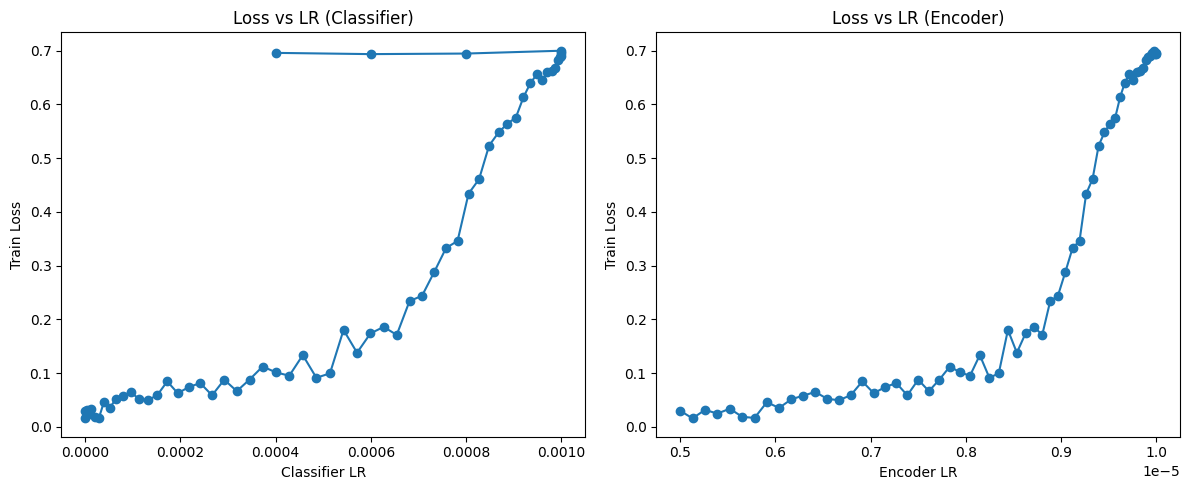

Final model saved


In [6]:

# ==========================================================
# 19. Main Execution
# ==========================================================

encoder = Encoder().to(device)

pretrained_path = "/kaggle/input/datasets/lilyofthevalley6666/pretrained-encoder-resnet-50/pretrained_encoder resNet-50.pth"

if os.path.exists(pretrained_path):
    print("Loading pretrained encoder...")
    # ✅ map_location ensures safe loading on both CPU and GPU machines
    encoder.load_state_dict(torch.load(pretrained_path, map_location=device))
else:
    print("Pretraining encoder...")
    pretrain(encoder, ssl_loader, epochs=60)
    encoder.load_state_dict(torch.load(
        "/kaggle/working/pretrained_encoder.pth", map_location=device
    ))



model = ThermoClassifier(encoder).to(device)

train_classifier(model, train_loader, val_loader, epochs=60)

evaluate(model, test_loader)

plot_training()
plot_lr_vs_loss()

torch.save(model.state_dict(), "/kaggle/working/final_thermo_model.pth")
print("Final model saved")